# Evaluating the Impact of Image Augmentation Strategies on CNN Architectures in Skin Lesion Classification

**DS 6050, SP 2026 - ML III: Deep Learning Project** *For Professor Heman Shakeri, PhD, University of Virginia*

---

### Team Members
* **Robert Ashby** | *University of Virginia, School of Data Science* | Fernandina Beach, Florida | gsr3qz@virginia.edu
* **Xavier Colbert** | *University of Virginia, School of Data Science* | Alexandria, Virginia | kxp3jj@virginia.edu
* **Jacob Kuchta** | *University of Virginia, School of Data Science* | Arlington, Virginia | mjk3ku@virginia.edu
* **Alysa Pugmire** | *University of Virginia, School of Data Science* | Richmond, Virginia | amp3xs@virginia.edu

# 02 — Baseline Modeling

This notebook runs the **Phase 1 image-only baseline** for all three CNN backbones:

- `resnet50`
- `efficientnet_b0`
- `densenet121`

All three models use the same:
- processed ISIC 2019 train/validation splits
- image size
- optimizer/loss setup
- epoch count
- evaluation metrics

The goal of this notebook is to produce a fair baseline comparison before any augmentation experiments.

In [1]:
from pathlib import Path
import sys
import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import balanced_accuracy_score, roc_auc_score, confusion_matrix, classification_report

In [2]:
# Config
SEED = 42
BACKBONES = ["resnet50", "efficientnet_b0", "densenet121"]

IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 5
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0
FREEZE_FEATURES = False
SAVE_CHECKPOINTS = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Device:", DEVICE)
print("Backbones:", BACKBONES)

Device: cuda
Backbones: ['resnet50', 'efficientnet_b0', 'densenet121']


In [3]:
# Paths
cwd = Path.cwd().resolve()
ROOT = cwd.parent if cwd.name.lower() == "code" else cwd
DATA = ROOT / "DATA"
PROCESSED = DATA / "processed"
SCRIPTS = ROOT / "scripts"

if str(SCRIPTS) not in sys.path:
    sys.path.append(str(SCRIPTS))

train_csv = PROCESSED / "isic2019" / "train.csv"
val_csv = PROCESSED / "isic2019" / "val.csv"
weights_json = PROCESSED / "class_weights.json"

OUT_ROOT = ROOT / "outputs"
CKPT_DIR = OUT_ROOT / "checkpoints"
FIG_DIR = OUT_ROOT / "figures" / "02_baseline_modeling"
METRIC_DIR = OUT_ROOT / "metrics"
PRED_DIR = OUT_ROOT / "preds"

for d in [CKPT_DIR, FIG_DIR, METRIC_DIR, PRED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("train_csv:", train_csv)
print("val_csv:  ", val_csv)
print("weights:  ", weights_json)

ROOT: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire
train_csv: /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/DATA/processed/isic2019/train.csv
val_csv:   /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/DATA/processed/isic2019/val.csv
weights:   /sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_ML_III_Deep_Learning_Project_Ashby_Colbert_Kuchta_Pugmire/DATA/processed/class_weights.json


In [4]:
train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)

# Normalize Windows-style paths for cross-platform use
def normalize_path_column(df, col):
    df = df.copy()
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace("\\", "/", regex=False)
    return df

train_df = normalize_path_column(train_df, "image_path")
val_df   = normalize_path_column(val_df, "image_path")

with open(weights_json, "r") as f:
    class_weights_dict = json.load(f)

required_cols = ["image_path", "label"]
for col in required_cols:
    if col not in train_df.columns:
        raise ValueError(f"Missing required column: {col}")

labels = sorted(train_df["label"].unique())
label_to_idx = {label: idx for idx, label in enumerate(labels)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

train_df["label_idx"] = train_df["label"].map(label_to_idx)
val_df["label_idx"] = val_df["label"].map(label_to_idx)

class_weight_tensor = torch.tensor(
    [class_weights_dict[label] for label in labels],
    dtype=torch.float32,
    device=DEVICE
)

print("Labels:", labels)
print("Train shape:", train_df.shape)
print("Val shape:  ", val_df.shape)
print("Class weights tensor:", class_weight_tensor)
print("Example normalized train paths:", train_df["image_path"].head(3).tolist())

Labels: ['AK', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']
Train shape: (21531, 22)
Val shape:   (3800, 22)
Class weights tensor: tensor([ 3.6518,  0.9530,  1.2069, 13.2580,  0.7001,  0.2459,  5.0400, 12.5180],
       device='cuda:0')
Example normalized train paths: ['DATA/isic2019/train/images/ISIC_2019_Training_Input/ISIC_0029767.jpg', 'DATA/isic2019/train/images/ISIC_2019_Training_Input/ISIC_0071877.jpg', 'DATA/isic2019/train/images/ISIC_2019_Training_Input/ISIC_0028390.jpg']


In [5]:
class ISICDataset(Dataset):
    def __init__(self, df, root, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.root = Path(root)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        rel_path = str(row["image_path"]).replace("\\", "/")
        image = Image.open(self.root / rel_path).convert("RGB")
        label = int(row["label_idx"])

        if self.transform is not None:
            image = self.transform(image)

        return image, label, rel_path


def make_phase1_transforms(image_size=224):
    normalize = transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

    train_tf = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        normalize,
    ])

    val_tf = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        normalize,
    ])

    return train_tf, val_tf

In [6]:
train_tf, val_tf = make_phase1_transforms(IMAGE_SIZE)

train_ds = ISICDataset(train_df, ROOT, transform=train_tf)
val_ds   = ISICDataset(val_df, ROOT, transform=val_tf)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

batch_images, batch_labels, batch_paths = next(iter(train_loader))
print("Batch image shape:", batch_images.shape)
print("Batch label shape:", batch_labels.shape)
print("Example paths:", batch_paths[:3])

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])
Example paths: ['DATA/isic2019/train/images/ISIC_2019_Training_Input/ISIC_0060962.jpg', 'DATA/isic2019/train/images/ISIC_2019_Training_Input/ISIC_0065692.jpg', 'DATA/isic2019/train/images/ISIC_2019_Training_Input/ISIC_0059687.jpg']


In [7]:
from resnet50_baseline import build_resnet50
from efficientnet_b0_baseline import build_efficientnet_b0
from densenet121_baseline import build_densenet121

MODEL_BUILDERS = {
    "resnet50": build_resnet50,
    "efficientnet_b0": build_efficientnet_b0,
    "densenet121": build_densenet121,
}

print("Model builders loaded:", list(MODEL_BUILDERS.keys()))

Model builders loaded: ['resnet50', 'efficientnet_b0', 'densenet121']


In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    n_samples = 0

    for images, targets, _ in loader:
        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        n_samples += batch_size

    return running_loss / max(n_samples, 1)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    n_samples = 0

    all_targets = []
    all_preds = []
    all_probs = []
    all_paths = []

    for images, targets, paths in loader:
        images = images.to(device)
        targets = targets.to(device)

        logits = model(images)
        loss = criterion(logits, targets)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        n_samples += batch_size

        all_targets.extend(targets.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_paths.extend(paths)

    avg_loss = running_loss / max(n_samples, 1)
    y_true = np.array(all_targets)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)

    bal_acc = balanced_accuracy_score(y_true, y_pred)

    try:
        macro_auc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
    except ValueError:
        macro_auc = np.nan

    return {
        "loss": avg_loss,
        "balanced_accuracy": bal_acc,
        "macro_auc": macro_auc,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "paths": all_paths,
    }

In [ ]:
comparison_rows = []
all_histories = {}

for backbone in BACKBONES:
    print("=" * 90)
    print(f"Running baseline for: {backbone}")
    print("=" * 90)

    build_fn = MODEL_BUILDERS[backbone]
    model = build_fn(
        num_classes=len(labels),
        pretrained=True,
        freeze_backbone=FREEZE_FEATURES
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=class_weight_tensor)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    history = {
        "epoch": [],
        "epoch_seconds": [],
        "train_loss": [],
        "val_loss": [],
        "val_balanced_accuracy": [],
        "val_macro_auc": [],
    }

    best_score = -np.inf
    best_ckpt_path = CKPT_DIR / f"{backbone}_phase1_best.pt"

    model_start_time = time.time()

    for epoch in range(1, EPOCHS + 1):
        epoch_start_time = time.time()

        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_metrics = evaluate(model, val_loader, criterion, DEVICE)

        epoch_seconds = time.time() - epoch_start_time

        current_score = val_metrics["macro_auc"]
        if np.isnan(current_score):
            current_score = val_metrics["balanced_accuracy"]

        if current_score > best_score:
            best_score = current_score
            if SAVE_CHECKPOINTS:
                torch.save(
                    {
                        "epoch": epoch,
                        "model_state_dict": model.state_dict(),
                        "label_to_idx": label_to_idx,
                        "backbone": backbone,
                        "image_size": IMAGE_SIZE,
                    },
                    best_ckpt_path
                )

        history["epoch"].append(epoch)
        history["epoch_seconds"].append(epoch_seconds)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_balanced_accuracy"].append(val_metrics["balanced_accuracy"])
        history["val_macro_auc"].append(val_metrics["macro_auc"])

        print(
            f"{backbone} | Epoch {epoch:02d} | "
            f"epoch_time={epoch_seconds/60:.2f} min | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_bal_acc={val_metrics['balanced_accuracy']:.4f} | "
            f"val_macro_auc={val_metrics['macro_auc']:.4f}"
        )

    total_minutes = (time.time() - model_start_time) / 60
    print(f"{backbone} finished in {total_minutes:.2f} minutes")

    history_df = pd.DataFrame(history)
    all_histories[backbone] = history_df
    history_df.to_csv(METRIC_DIR / f"{backbone}_phase1_history.csv", index=False)

    # Loss curve
    plt.figure(figsize=(8, 4))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{backbone} Phase 1 — Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{backbone}_phase1_loss_curve.png", dpi=200, bbox_inches="tight")
    plt.show()

    # Validation metric curve
    plt.figure(figsize=(8, 4))
    plt.plot(history_df["epoch"], history_df["val_balanced_accuracy"], label="val_balanced_accuracy")
    plt.plot(history_df["epoch"], history_df["val_macro_auc"], label="val_macro_auc")
    plt.xlabel("Epoch")
    plt.ylabel("Metric")
    plt.title(f"{backbone} Phase 1 — Validation Metrics")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{backbone}_phase1_metric_curve.png", dpi=200, bbox_inches="tight")
    plt.show()

    # Reload best checkpoint
    if SAVE_CHECKPOINTS:
        checkpoint = torch.load(best_ckpt_path, map_location=DEVICE)
        model.load_state_dict(checkpoint["model_state_dict"])

    val_metrics = evaluate(model, val_loader, criterion, DEVICE)
    y_true = val_metrics["y_true"]
    y_pred = val_metrics["y_pred"]
    y_prob = val_metrics["y_prob"]

    # Confusion matrix: counts
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(labels)))

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{backbone} Phase 1 — Validation Confusion Matrix (Counts)")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8)

    fig.colorbar(im)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{backbone}_phase1_confusion_matrix_counts.png", dpi=200, bbox_inches="tight")
    plt.show()

    # Confusion matrix: row-normalized percentages
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_pct = np.nan_to_num(cm_pct) * 100.0

    from matplotlib.colors import LinearSegmentedColormap
    red_green_cmap = LinearSegmentedColormap.from_list(
        "red_green",
        ["#b2182b", "#1a9850"]
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm_pct, cmap=red_green_cmap, vmin=0, vmax=100)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{backbone} Phase 1 — Row-Normalized Validation Confusion Matrix (%)")

    for i in range(cm_pct.shape[0]):
        for j in range(cm_pct.shape[1]):
            ax.text(j, i, f"{cm_pct[i, j]:.1f}%", ha="center", va="center", fontsize=8)

    fig.colorbar(im)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{backbone}_phase1_confusion_matrix_percent.png", dpi=200, bbox_inches="tight")
    plt.show()

    # Classification report
    report = classification_report(
        y_true,
        y_pred,
        target_names=labels,
        output_dict=True,
        zero_division=0
    )
    report_df = pd.DataFrame(report).T
    report_df.to_csv(METRIC_DIR / f"{backbone}_phase1_classification_report.csv")

    # Saved predictions
    pred_df = pd.DataFrame({
        "image_path": val_metrics["paths"],
        "true_idx": y_true,
        "pred_idx": y_pred,
        "true_label": [idx_to_label[i] for i in y_true],
        "pred_label": [idx_to_label[i] for i in y_pred],
        "max_prob": y_prob.max(axis=1),
    })

    for i, label in enumerate(labels):
        pred_df[f"prob_{label}"] = y_prob[:, i]

    pred_df.to_csv(PRED_DIR / f"{backbone}_phase1_val_predictions.csv", index=False)

    comparison_rows.append({
        "backbone": backbone,
        "best_val_macro_auc": history_df["val_macro_auc"].max(),
        "best_val_balanced_accuracy": history_df["val_balanced_accuracy"].max(),
        "final_val_loss": history_df["val_loss"].iloc[-1],
        "epochs": EPOCHS,
        "checkpoint": str(best_ckpt_path) if SAVE_CHECKPOINTS else ""
    })

Running baseline for: resnet50
resnet50 | Epoch 01 | epoch_time=5.74 min | train_loss=1.3187 | val_loss=0.9816 | val_bal_acc=0.6599 | val_macro_auc=0.9322


,backbone,best_val_macro_auc,best_val_balanced_accuracy,final_val_loss,epochs,checkpoint
0,resnet50,0.961170,0.745675,0.882972,5,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
1,efficientnet_b0,0.960847,0.752566,0.813673,5,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...
2,densenet121,0.955667,0.745330,0.847659,5,/sfs/gpfs/tardis/home/gsr3qz/UVA_MSDS_DS_6050_...


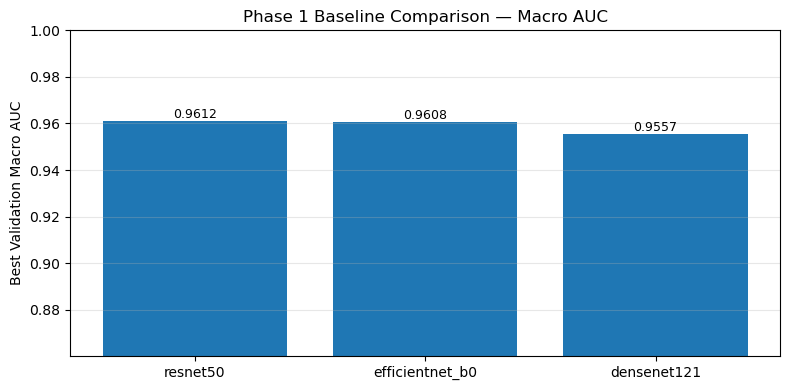

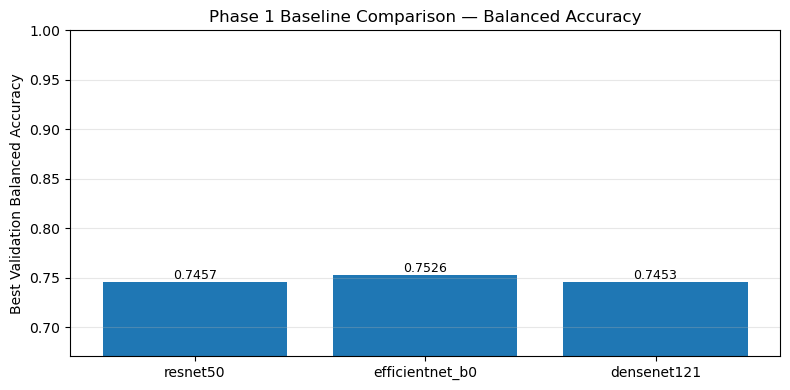

In [10]:
results_df = pd.DataFrame(comparison_rows).sort_values(
    by="best_val_macro_auc",
    ascending=False
).reset_index(drop=True)

display(results_df)
results_df.to_csv(METRIC_DIR / "baseline_backbone_comparison.csv", index=False)

# Dynamic y-axis floors
macro_auc_min = results_df["best_val_macro_auc"].min()
bal_acc_min = results_df["best_val_balanced_accuracy"].min()

macro_auc_floor = 0.9 * macro_auc_min
bal_acc_floor = 0.9 * bal_acc_min

# Macro AUC plot
plt.figure(figsize=(8, 4))
bars = plt.bar(results_df["backbone"], results_df["best_val_macro_auc"])
plt.ylabel("Best Validation Macro AUC")
plt.title("Phase 1 Baseline Comparison — Macro AUC")
plt.ylim(macro_auc_floor, 1.0)
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, results_df["best_val_macro_auc"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(FIG_DIR / "baseline_backbone_comparison_macro_auc.png", dpi=200, bbox_inches="tight")
plt.show()

# Balanced Accuracy plot
plt.figure(figsize=(8, 4))
bars = plt.bar(results_df["backbone"], results_df["best_val_balanced_accuracy"])
plt.ylabel("Best Validation Balanced Accuracy")
plt.title("Phase 1 Baseline Comparison — Balanced Accuracy")
plt.ylim(bal_acc_floor, 1.0)
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, results_df["best_val_balanced_accuracy"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(FIG_DIR / "baseline_backbone_comparison_bal_acc.png", dpi=200, bbox_inches="tight")
plt.show()

# Next steps

- Baseline comparison across all three CNN backbones
- Baseline model selection
- Error analysis from saved predictions and metrics
- Augmentation experiments in `03_augmentation_experiments.ipynb`